## 1. Setup and Imports

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm

# Import custom modules
from model import create_vit_classifier, count_parameters
from dataset import BrainTumorDataset, create_dataloaders, get_class_weights
from train import Trainer
from evaluate import Evaluator, CrossDatasetEvaluator, save_evaluation_results
from utils import (
    plot_training_history, plot_confusion_matrix,
    set_seed, get_device, create_experiment_dirs
)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All modules imported successfully!")

All modules imported successfully!


## 2. Configuration

In [8]:
# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()

# Hyperparameters
CONFIG = {
    # Data
    'train_metadata': 'Dataset/preprocessed_data/train_metadata.csv',
    'val_metadata': 'Dataset/preprocessed_data/val_metadata.csv',
    'test_metadata': 'Dataset/preprocessed_data/test_metadata.csv',
    'batch_size': 16,
    'num_workers': 4,
    
    # Model
    'image_size': 224,
    'patch_size': 16,
    'num_classes': 2,  # Binary: tumor vs no tumor
    'embed_dim': 768,
    'depth': 12,
    'num_heads': 12,
    'mlp_ratio': 4,
    'dropout': 0.1,
    
    # Training
    'num_epochs': 10,
    'learning_rate': 1e-4,
    'weight_decay': 0.05,
    'patience': 15,
    
    # Paths
    'checkpoint_dir': 'experiments/checkpoints',
    'log_dir': 'experiments/logs',
    'results_dir': 'experiments/results'
}

# Create experiment directories
exp_dirs = create_experiment_dirs('experiments')

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Using CPU
Configuration:
  train_metadata: Dataset/preprocessed_data/train_metadata.csv
  val_metadata: Dataset/preprocessed_data/val_metadata.csv
  test_metadata: Dataset/preprocessed_data/test_metadata.csv
  batch_size: 16
  num_workers: 4
  image_size: 224
  patch_size: 16
  num_classes: 2
  embed_dim: 768
  depth: 12
  num_heads: 12
  mlp_ratio: 4
  dropout: 0.1
  num_epochs: 10
  learning_rate: 0.0001
  weight_decay: 0.05
  patience: 15
  checkpoint_dir: experiments/checkpoints
  log_dir: experiments/logs
  results_dir: experiments/results


## 3. Load Data

In [9]:
# Create dataloaders
train_loader, val_loader, test_loader, class_names = create_dataloaders(
    train_csv=CONFIG['train_metadata'],
    val_csv=CONFIG['val_metadata'],
    test_csv=CONFIG['test_metadata'],
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    augment_train=True
)

print(f"\nDataset sizes:")
print(f"  Training:   {len(train_loader.dataset):,} samples")
print(f"  Validation: {len(val_loader.dataset):,} samples")
print(f"  Test:       {len(test_loader.dataset):,} samples")

print(f"\nClasses: {class_names}")

# Calculate class weights
class_weights = get_class_weights(CONFIG['train_metadata'])
print(f"\nClass weights: {class_weights}")


Dataset sizes:
  Training:   5,793 samples
  Validation: 1,242 samples
  Test:       1,242 samples

Classes: ['no tumor', 'tumor']

Class weights: tensor([0.9947, 1.0054])


## 4. Visualize Sample Data

e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


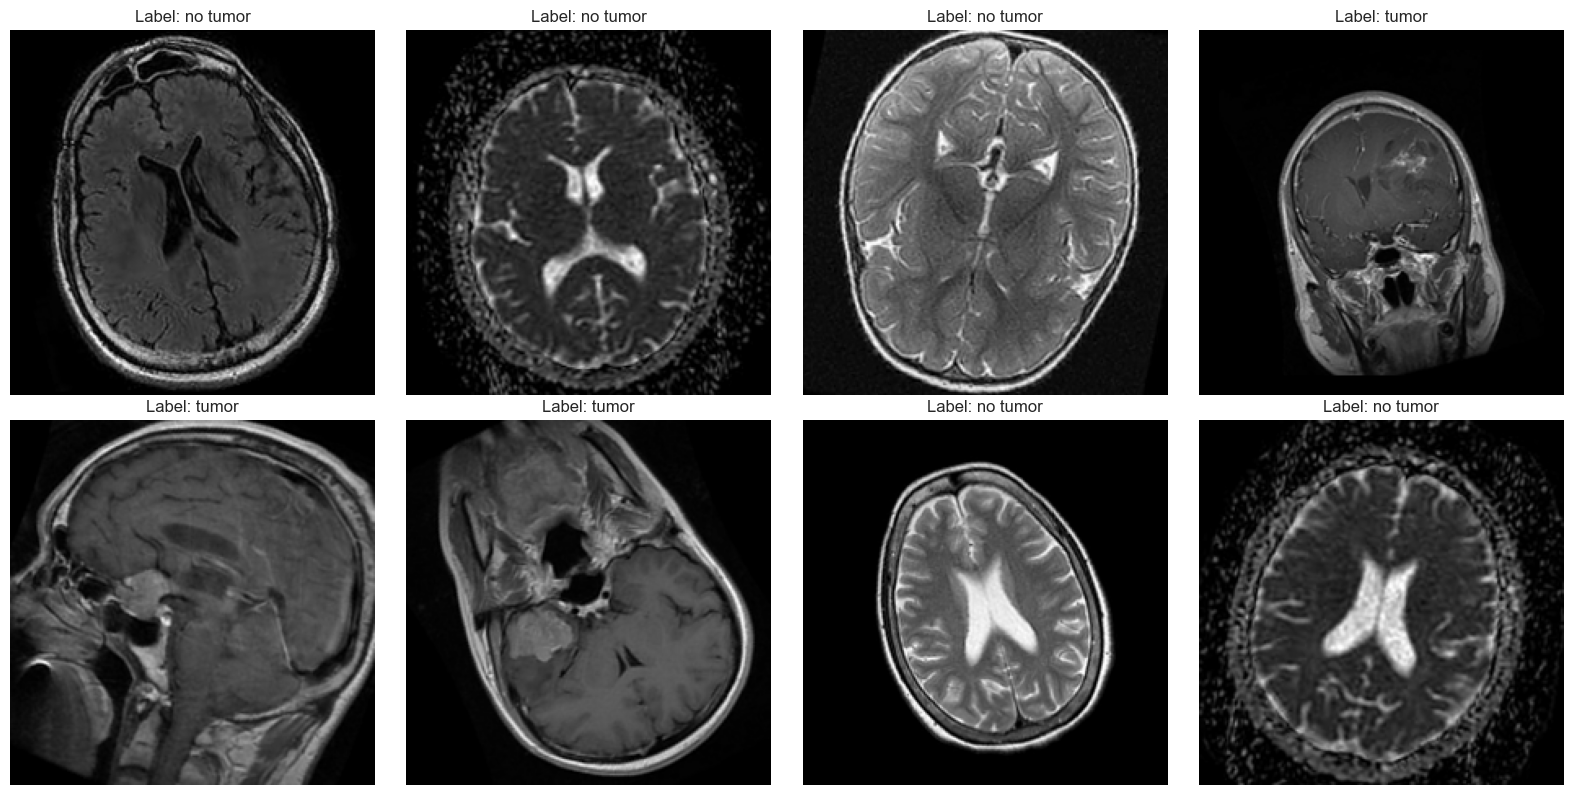

In [4]:
# Get a batch of training data
images, labels = next(iter(train_loader))

# Plot sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    # Denormalize for visualization (approximate)
    img = (img - img.min()) / (img.max() - img.min())
    
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {class_names[labels[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('experiments/results/figures/sample_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Create Model

In [14]:
# Create Vision Transformer model
model = create_vit_classifier(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['image_size'],
    in_channels=3
 )

model = model.to(device)

# Count parameters
num_params = count_parameters(model)
print(f"\nModel: Vision Transformer")
print(f"Total parameters: {num_params:,}")
print(f"Model size: ~{num_params * 4 / (1024**2):.2f} MB")


Model: Vision Transformer
Total parameters: 85,800,194
Model size: ~327.30 MB


## 6. Setup Training

In [15]:
# Loss function (with class weights)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
 )

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-6
)

# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir=CONFIG['checkpoint_dir'],
    log_dir=CONFIG['log_dir']
    # patience is not a Trainer argument; early stopping is set in train()
 )
print("Training setup complete!")

Training setup complete!


## 7. Train Model

In [7]:
# Train the model
print("Starting training...\n")

history = trainer.train(num_epochs=CONFIG['num_epochs'])

print("\nTraining complete!")

Starting training...

Starting training for 10 epochs...
Device: cpu
Model parameters: 85,800,194


Epoch 1 [Train]: 100%|██████████| 363/363 [2:31:33<00:00, 25.05s/it, loss=0.471]  

Epoch 1 [Val]:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 1 [Val]: 100%|██████████| 78/78 [07:18<00:00,  5.63s/it, loss=0.384] 




Epoch 1/10 (9532.5s)
  Train - Loss: 0.6469, Acc: 0.6701
  Val   - Loss: 0.3758, Acc: 0.8663
  Val   - P: 0.8683, R: 0.8663, F1: 0.8661
  ✓ New best model saved! (Val Acc: 0.8663)
----------------------------------------------------------------------
  ✓ New best model saved! (Val Acc: 0.8663)
----------------------------------------------------------------------


Epoch 2 [Train]:   0%|          | 0/363 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 2 [Train]: 100%|██████████| 363/363 [2:14:25<00:00, 22.22s/it, loss=0.0418] 

Epoch 2 [Val]:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 2 [Val]:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument i


Epoch 2/10 (8475.2s)
  Train - Loss: 0.4492, Acc: 0.7973
  Val   - Loss: 0.5622, Acc: 0.7560
  Val   - P: 0.8271, R: 0.7560, F1: 0.7424
----------------------------------------------------------------------


...


Epoch 8/10 (8530.6s)
  Train - Loss: 0.2482, Acc: 0.9121
  Val   - Loss: 0.2328, Acc: 0.9147
  Val   - P: 0.9194, R: 0.9147, F1: 0.9144
  ✓ New best model saved! (Val Acc: 0.9147)
----------------------------------------------------------------------
  ✓ New best model saved! (Val Acc: 0.9147)
----------------------------------------------------------------------


Epoch 9 [Train]:   0%|          | 0/363 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 9 [Train]: 100%|██████████| 363/363 [2:13:07<00:00, 22.00s/it, loss=0.0149]  

Epoch 9 [Val]:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then devi


Epoch 9/10 (8397.5s)
  Train - Loss: 0.2291, Acc: 0.9151
  Val   - Loss: 0.1927, Acc: 0.9348
  Val   - P: 0.9355, R: 0.9348, F1: 0.9348
  ✓ New best model saved! (Val Acc: 0.9348)
----------------------------------------------------------------------
  ✓ New best model saved! (Val Acc: 0.9348)
----------------------------------------------------------------------


Epoch 10 [Train]:   0%|          | 0/363 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 10 [Train]: 100%|██████████| 363/363 [2:40:20<00:00, 26.50s/it, loss=0.00665]  

Epoch 10 [Val]:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then 


Epoch 10/10 (10039.3s)
  Train - Loss: 0.2158, Acc: 0.9218
  Val   - Loss: 0.1956, Acc: 0.9332
  Val   - P: 0.9344, R: 0.9332, F1: 0.9331
----------------------------------------------------------------------

Training completed!
Best validation accuracy: 0.9348

Training complete!
----------------------------------------------------------------------

Training completed!
Best validation accuracy: 0.9348

Training complete!


## 8. Plot Training History

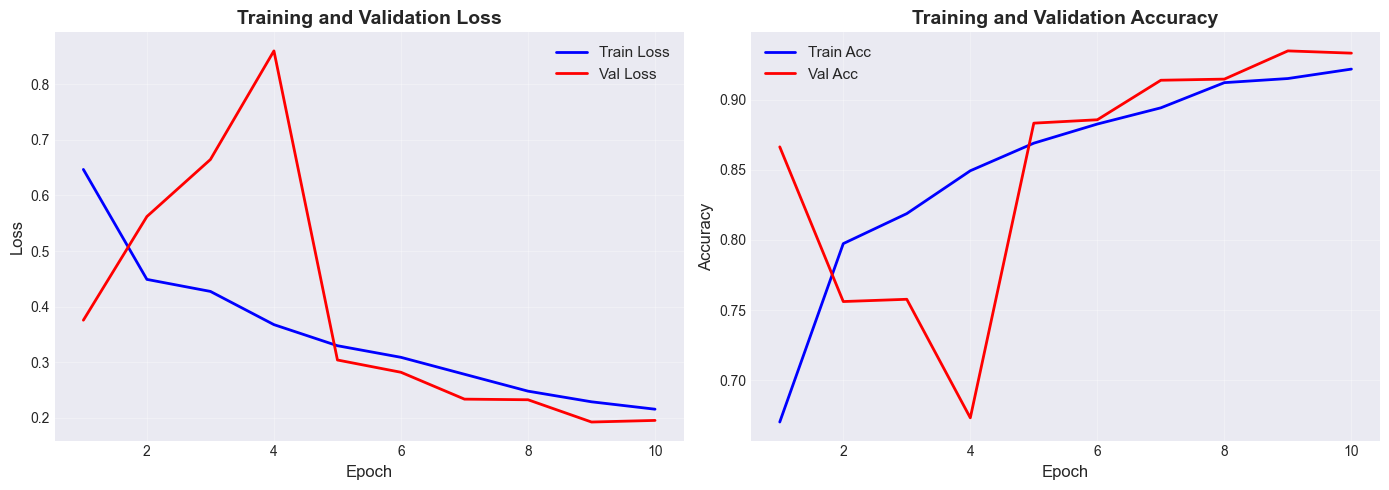


Best Validation Accuracy: 0.9348 at Epoch 9


In [8]:
# Plot training curves
history_path = Path(CONFIG['checkpoint_dir']) / 'training_history.json'

if history_path.exists():
    plot_training_history(
        history_path,
        save_path='experiments/results/figures/training_history.png'
    )
else:
    print("Training history not found.")

## 9. Evaluate on Test Set

In [9]:
# Load best model
best_checkpoint_path = Path(CONFIG['checkpoint_dir']) / 'best_model.pth'

if best_checkpoint_path.exists():
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Best validation accuracy: {checkpoint['best_val_acc']:.4f}")
else:
    print("Best model checkpoint not found. Using current model.")

Loaded best model from epoch 9
Best validation accuracy: 0.9348


In [16]:
# Create evaluator
evaluator = Evaluator(model, device=device)

# Evaluate on test set
print("Evaluating on test set...\n")
test_metrics = evaluator.evaluate(test_loader, class_names=class_names)

# Print metrics
evaluator.print_metrics(test_metrics, class_names=class_names)

# Save results
save_evaluation_results(
    test_metrics,
    'experiments/results/test_metrics.json',
)

Evaluating on test set...



Evaluating:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Evaluating: 100%|██████████| 78/78 [05:34<00:00,  4.28s/it]


EVALUATION METRICS

Overall Metrics:
  Accuracy:           0.4340
  Precision (macro):  0.3764
  Recall (macro):     0.4356
  F1-Score (macro):   0.3581
  ROC-AUC:            0.3273

Per-Class Metrics:

  no tumor:
    Precision: 0.2932
    Recall:    0.0897
    F1-Score:  0.1374

  tumor:
    Precision: 0.4596
    Recall:    0.7816
    F1-Score:  0.5788


Results saved to experiments\results\test_metrics.json


## 10. Confusion Matrix

Getting predictions:   0%|          | 0/78 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Getting predictions: 100%|██████████| 78/78 [05:45<00:00,  4.43s/it]


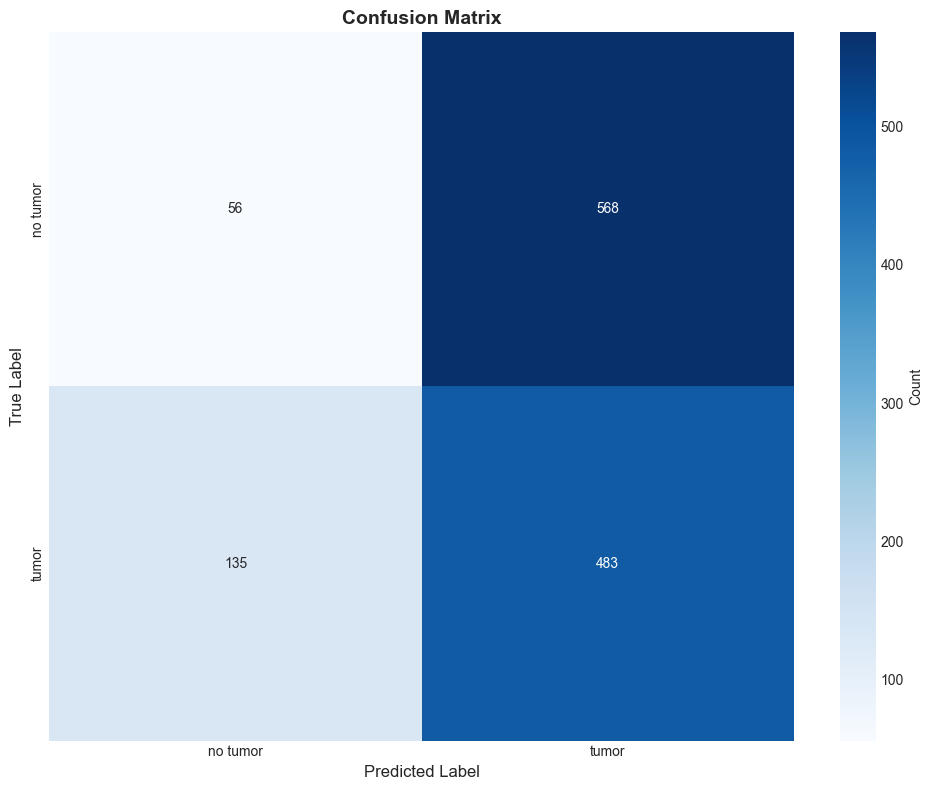


Classification Report:
              precision    recall  f1-score   support

    no tumor     0.2932    0.0897    0.1374       624
       tumor     0.4596    0.7816    0.5788       618

    accuracy                         0.4340      1242
   macro avg     0.3764    0.4356    0.3581      1242
weighted avg     0.3760    0.4340    0.3570      1242



In [17]:
# Get predictions for confusion matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Getting predictions'):
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Plot confusion matrix
plot_confusion_matrix(
    all_labels,
    all_preds,
    class_names,
    save_path='experiments/results/figures/confusion_matrix.png'
)

## 11. Cross-Dataset Evaluation (Optional)

In [ ]:
# For cross-dataset evaluation, you need to create separate test loaders
# for each dataset you want to evaluate on

# Example: Evaluate on multiple datasets
# Uncomment and modify as needed

# from dataset import BrainTumorDataset

# # Create dataset-specific test loaders
# dataset1_test = BrainTumorDataset(
#     metadata_csv='path/to/dataset1/test_metadata.csv',
#     apply_augmentation=False
# )
# dataset1_loader = DataLoader(
#     dataset1_test,
#     batch_size=CONFIG['batch_size'],
#     shuffle=False,
#     num_workers=CONFIG['num_workers']
# )

# dataset2_test = BrainTumorDataset(
#     metadata_csv='path/to/dataset2/test_metadata.csv',
#     apply_augmentation=False
# )
# dataset2_loader = DataLoader(
#     dataset2_test,
#     batch_size=CONFIG['batch_size'],
#     shuffle=False,
#     num_workers=CONFIG['num_workers']
# )

# # Evaluate on all datasets
# cross_evaluator = CrossDatasetEvaluator(model, device=device)
# dataloaders_dict = {
#     'Dataset1': dataset1_loader,
#     'Dataset2': dataset2_loader,
#     'Dataset3': test_loader  # Your test set
# }

# results = cross_evaluator.evaluate_all_datasets(
#     dataloaders_dict,
#     class_names=class_names
# )

# # Save cross-dataset results
# save_evaluation_results(
#     results,
#     'experiments/results/cross_dataset_results.json'
# )

print("Cross-dataset evaluation section (modify as needed)")

## 12. Visualize Predictions

e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


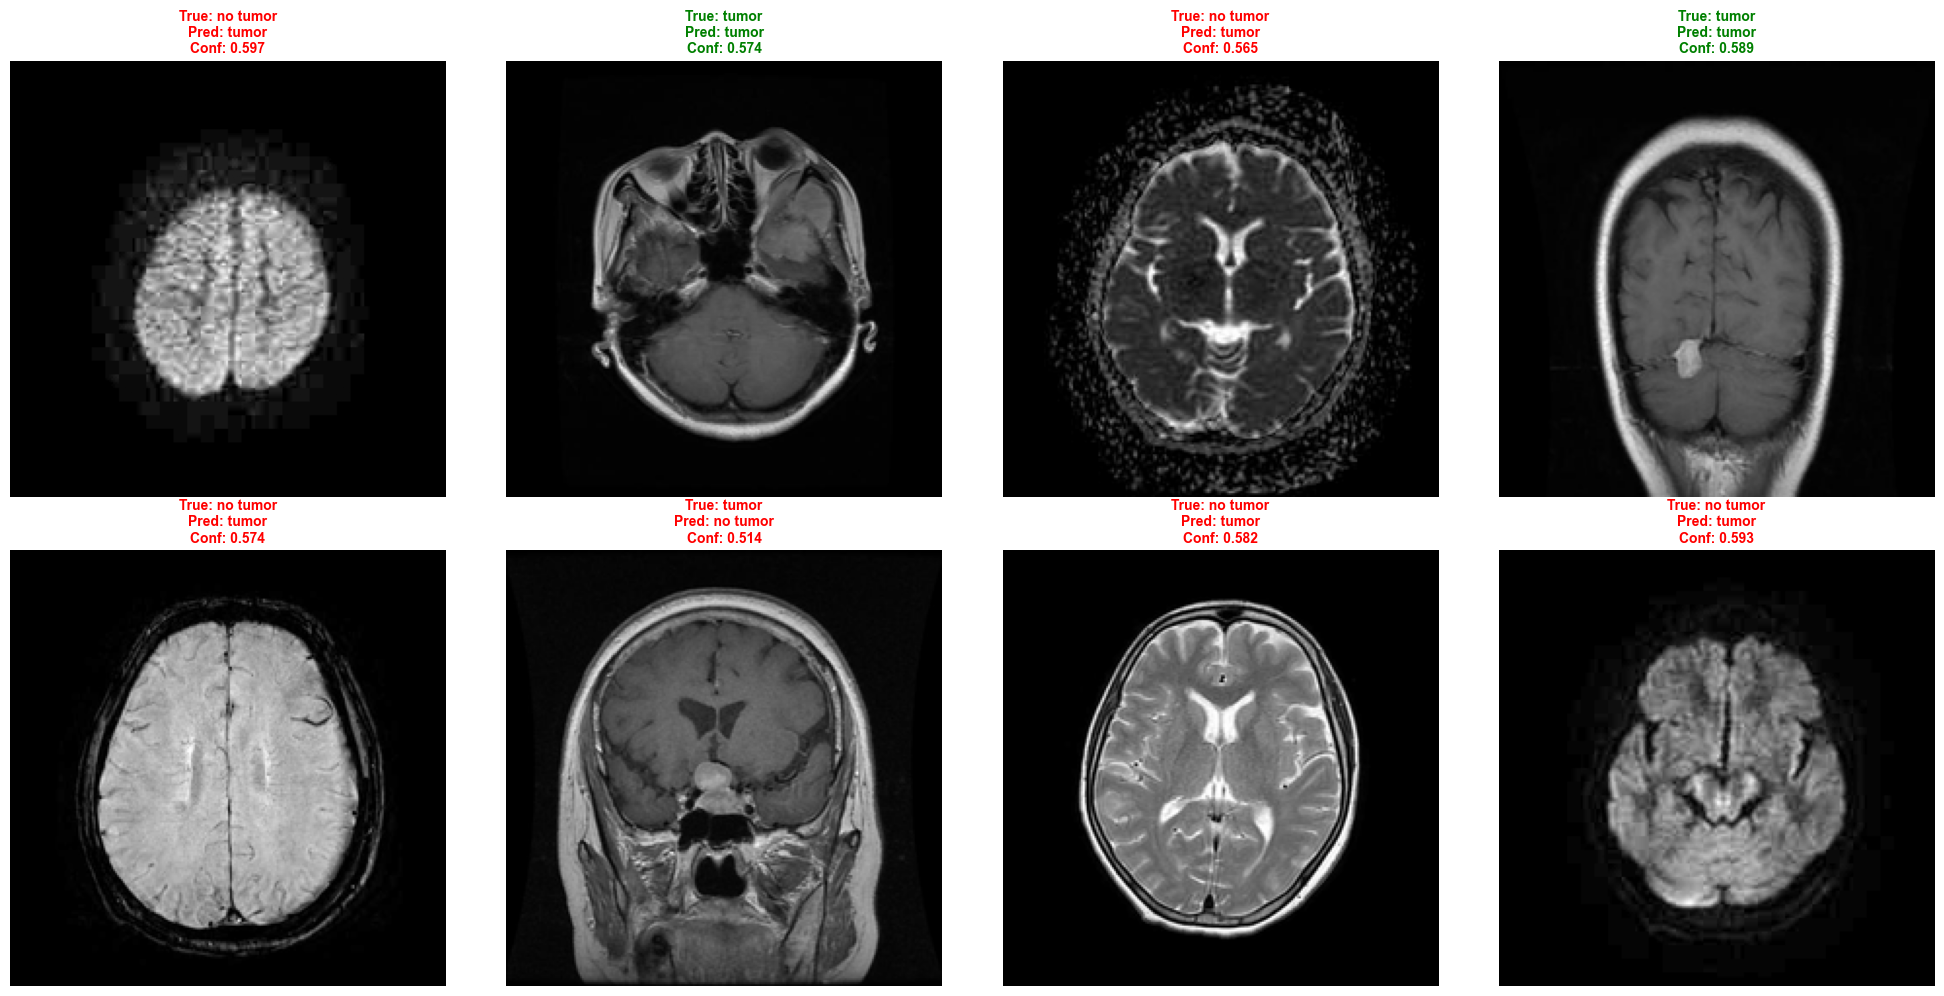

In [18]:
# Visualize some predictions
model.eval()

# Get a batch of test data
batch = next(iter(test_loader))
if len(batch) == 3:
    test_images, test_labels, _ = batch
else:
    test_images, test_labels = batch
test_images = test_images.to(device)

with torch.no_grad():
    outputs = model(test_images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(8):
    img = test_images[i].cpu().permute(1, 2, 0).numpy()
    # Denormalize for visualization
    img = (img - img.min()) / (img.max() - img.min())
    
    true_label = class_names[test_labels[i]]
    pred_label = class_names[preds[i]]
    confidence = probs[i, preds[i]].item()
    
    color = 'green' if preds[i] == test_labels[i] else 'red'
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}",
        color=color,
        fontsize=10,
        fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('experiments/results/figures/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary

In [19]:
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nModel: Vision Transformer")
print(f"Parameters: {num_params:,}")
print(f"\nDataset:")
print(f"  Training samples:   {len(train_loader.dataset):,}")
print(f"  Validation samples: {len(val_loader.dataset):,}")
print(f"  Test samples:       {len(test_loader.dataset):,}")
print(f"\nTest Performance:")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision_macro']:.4f}")
print(f"  Recall:    {test_metrics['recall_macro']:.4f}")
print(f"  F1-Score:  {test_metrics['f1_macro']:.4f}")
print("\n" + "="*60)
print("\nResults saved to: experiments/results/")
print("Checkpoints saved to: experiments/checkpoints/")
print("TensorBoard logs: experiments/logs/")
print("\nTo view TensorBoard: tensorboard --logdir=experiments/logs")
print("="*60)


TRAINING SUMMARY

Model: Vision Transformer
Parameters: 85,800,194

Dataset:
  Training samples:   5,793
  Validation samples: 1,242
  Test samples:       1,242

Test Performance:
  Accuracy:  0.4340
  Precision: 0.3764
  Recall:    0.4356
  F1-Score:  0.3581


Results saved to: experiments/results/
Checkpoints saved to: experiments/checkpoints/
TensorBoard logs: experiments/logs/

To view TensorBoard: tensorboard --logdir=experiments/logs
